# *Xeus-Octave*: A native Octave kernel for jupyter with advanced visualization

*Xeus-Octave* is an Octave kernel for Jupyter built with Xeus, a C++ framework
for building Jupyter kernels, which means that it is completely native, and does
not run a virtual Octave session in a forked process.

Thanks to its being native, xeus-octave has access to the internal representation
of all Octave objects, and thus it is able to provide advanced visualisation of
many types with ease.

## Native Octave plots

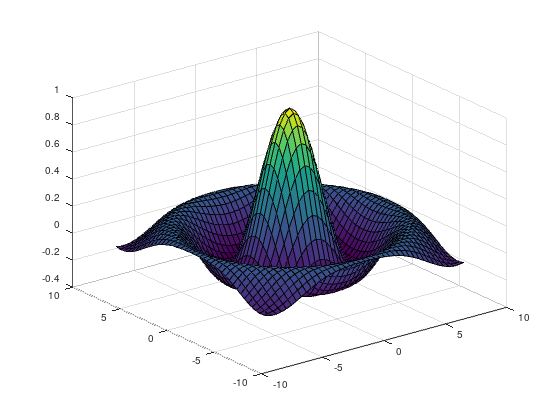

In [1]:
graphics_toolkit("notebook")  % The default
sombrero

## Advanced plots using [Plotly](https://github.com/plotly/plotly.js), with zoom, cursors, and hover tooltips (experimental)

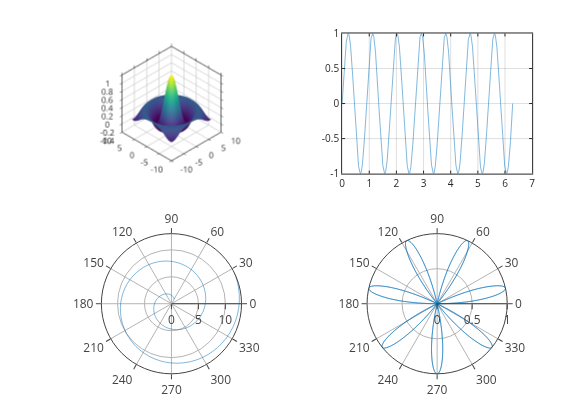

In [2]:
graphics_toolkit("plotly")

a = [1:0.1:13];
theta = linspace (0,2*pi,1000);
rho = sin (7*theta);

subplot(2,2,1);
sombrero()
grid on;
box on;

subplot(2,2,2);
plot(theta, rho);
grid on;
box on;

subplot(2,2,3);
polar(a,a)
grid on;
box on;

subplot(2,2,4);
polar(theta, rho);
grid on;
box on;

## [Plotly](https://github.com/plotly/plotly.js) plot with interactive legend

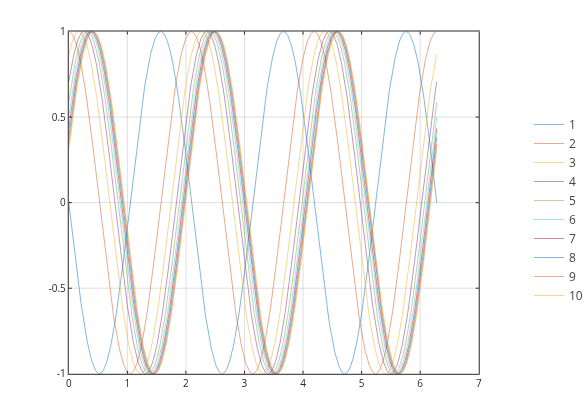

In [3]:
graphics_toolkit("plotly")
displayformat plotly_interactive_legend true

a = [1:0.1:13];
theta = linspace (0,2*pi,1000);
for(i=[1:10])
    rho = sin (3*theta+pi()/i);
    plot(theta,rho,[";" num2str(i) ";"]);
    grid on;
    hold on
endfor

## Matrices displayed as tables or $\LaTeX$

In [13]:
displayformat matrix latex
m

m =    1   1   1
   1   1   1
   1   1   1


In [3]:
displayformat include_comment true

In [10]:
#A table matrix: 
displayformat matrix html
m = ones(3,3) #c
disp("")
#And a latex one:\n
displayformat matrix latex;
m #d
1+1#2

#A table matrix: 


m,1,2,3
1,1,1,1
2,1,1,1
3,1,1,1



#And a latex one:



m =    1   1   1
   1   1   1
   1   1   1 #d


ans = 2#2


## Structs displayed as interactive tree views

In [7]:
struct(
    "name","Alice",
    "age", 33,
    "knows_octave", true,
    "pets", [
        struct("name", "Rex", "type", "Dog"),
        struct("name", "Felix", "type", "Cat")
    ]
)

ans =     name = Alice
    age = 33
    knows_octave = 1
    pets =

      2x1 struct array containing the fields:

        name
        type



## Symbolic classes displayed in $\LaTeX$

In [6]:
pkg load symbolic

syms x

#function
f = (sin(x/2))^3 # sin
#differential
diff(f, x) #diff
1+1 #1

Symbolic pkg v3.2.2: Python communication link active, SymPy v1.14.0.
#function


#differential


ans = 2 # sin


## Input support

In [12]:
name = input("Enter value: ")

Enter value:  2


name = 2


## Formatted help 

In [13]:
plot?

‘-’,Use solid lines (default).
‘--’,Use dashed lines.
‘:’,Use dotted lines.
‘-.’,Use dash-dotted lines.
‘+’,crosshair
‘o’,circle
‘*’,star
‘.’,point
‘x’,cross
‘|’,vertical line
‘_’,horizontal line


## Example: notch filter

### Parameters

In [14]:
displayformat include_comment true

In [37]:
# comm
w0 = 2*pi*1000       % Target frequency
a = 1                # a
# comm


Q = 100              % Analog selectivity
Tc = 1/50e3          % Sampling time    

# comm


w0 = 6283.2       % Target frequency


a = 1                # a


# comm


Q = 100              % Analog selectivity


Tc = 2.0000e-05          % Sampling time    


### Filter design

The analog solution has the following transfer function:

In [17]:
pkg load signal
pkg load control

%% Analog solution
s = tf('s');
N = 1+(s/w0)^2;                  
D = 1 + s/(Q*w0) + (s/w0)^2;
F = N/D                          % Analog notch filter                

%% Analog solution


Continuous-time model.



The discrete solution has the following transfer function:

In [27]:
F_d = c2d(F,Tc,'zoh')            % Discretisation   

Sampling time: 2e-05 s
Discrete-time model.



### Bode diagram

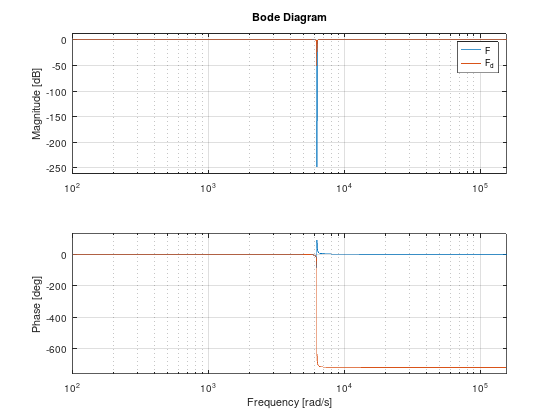

In [19]:
graphics_toolkit("notebook")
bode(F,F_d);
legend("F", "F_d")